# Modelo convolucional 1D

Entrenamiento del modelo convolucional descrito en la memoria (apartado *Modelo convolucional 1D*).

Planteamiento de superresolución:

1. El espectro de Gaia se interpola linealmente sobre la malla de longitudes de onda de SDSS, de modo que entrada y salida quedan alineadas punto a punto.
2. Una red convolucional residual aprende la **corrección** que hay que aplicar sobre el espectro interpolado (conexión residual global), en lugar de generar el espectro completo desde cero.
3. Cada espectro se normaliza con la mediana de su propio flujo, la entrada con la de Gaia y el objetivo con la de SDSS, igual que en el resto de arquitecturas del trabajo, de modo que sus métricas de entrenamiento son comparables entre sí.

In [ ]:
import sys

import numpy as np
from pathlib import Path

# 'services', 'model_functions' e 'iSpec_functions' están en 'models', así que
# hay que poner esa carpeta en 'sys.path' antes de importarlos. Para eso
# localizamos 'solution' subiendo desde el directorio de trabajo, sin suponer
# dónde arranca el kernel: sirve tanto la carpeta de este cuaderno como 'models'
# o la raíz del repositorio. Su marca es el fichero 'pyproject.toml'. iSpec
# tampoco se instala como dependencia, pero de montarlo se encarga
# 'iSpec_functions', que lo añade a 'sys.path' al importarse.
SOLUTION_DIR = next(
    candidate
    for parent in (Path.cwd(), *Path.cwd().parents)
    for candidate in (parent, parent / "solution")
    if (candidate / "pyproject.toml").is_file()
)

sys.path.insert(0, str(SOLUTION_DIR / "models"))

from services.paths import DATA_DIR, model_paths, test_data_path

# Ficheros que deja el entrenamiento, nombrados por la convención que comparten
# todos los cuadernos y que reúne 'services/paths.py': el modelo en esta misma
# carpeta, por ser la salida del cuaderno; a su lado 'training' con el registro
# de cómo se entrenó; y fuera de ella las predicciones, en
# 'models/data/predictions', y la tabla del análisis con iSpec, en
# 'models/data/ispec_deviations': no son un checkpoint del entrenamiento sino
# el dato que consume la comparativa entre arquitecturas.
MODEL_PATH, HISTORY_PATH, SUMMARY_PATH, PREDICTIONS_PATH, ISPEC_PATH = (
    model_paths("cnn_v1", "cnn")
)

# El conjunto de test que consumen las celdas de análisis va en
# 'models/data/test', carpeta común a todos los cuadernos porque todos parten
# del mismo conjunto de test. Esta celda no carga datos, de modo que la recarga
# de una sesión anterior solo necesita ejecutar esta celda y la de recarga.
TEST_DATA_PATH = test_data_path("cnn_v1")

# Tamaño de lote del entrenamiento, guardado también en el resumen
batch_size = 64

print("Carpeta de trabajo:", SOLUTION_DIR)

Carpeta de trabajo: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution


In [2]:
# El nombre del fichero puede llevar la fecha de generación como prefijo
candidates = (
    sorted(DATA_DIR.glob("*processed_data_no_duplicates.npz"))
    + sorted(DATA_DIR.glob("*processed_data.npz"))
)
processed_path = candidates[0]
print("Usando:", processed_path)

data = np.load(processed_path)
print(data.files)

Usando: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/data/2026-08-16_processed_data_no_duplicates.npz
['X_train', 'X_val', 'X_test', 'X_id_train', 'X_id_val', 'X_id_test', 'X_err_train', 'X_err_val', 'X_err_test', 'y_train', 'y_val', 'y_test', 'y_id_train', 'y_id_val', 'y_id_test', 'y_ivar_train', 'y_ivar_val', 'y_ivar_test', 'gaia_wavelength', 'sdss_wavelength']


In [3]:
# Datos de entrada Gaia
X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]

# Datos objetivo SDSS
y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]

# IDs de Gaia y SDSS
X_id_test = data["X_id_test"]
y_id_test = data["y_id_test"]

# Varianza inversa de SDSS, con la que se pondera el chi cuadrado
y_ivar_test = data["y_ivar_test"]

# Longitudes de onda
gaia_wavelength = data["gaia_wavelength"]
sdss_wavelength = data["sdss_wavelength"]

print("Gaia:", X_train.shape, "| SDSS:", y_train.shape)

Gaia: (32656, 201) | SDSS: (32656, 2666)


Normalizamos cada espectro con la mediana de su propio flujo absoluto: la entrada de Gaia con la suya y el objetivo de SDSS con la suya. Como ambos flujos están en las mismas unidades y los pares con escalas incoherentes ya se descartaron en el preprocesado, las dos escalas son parecidas y los dos espectros normalizados quedan en una escala cercana a 1.

In [4]:
from services.normalization import normalize_splits

# Escala por espectro: la mediana de su propio flujo absoluto, la de Gaia para
# la entrada y la de SDSS para el objetivo
X_train_norm, X_val_norm, X_test_norm, X_scale_test = normalize_splits(
    X_train, X_val, X_test
)
y_train_norm, y_val_norm, y_test_norm, y_scale_test = normalize_splits(
    y_train, y_val, y_test
)

Interpolamos el espectro de Gaia sobre la malla de longitudes de onda de SDSS. Esta versión interpolada es la entrada de la red y también la base sobre la que se aplica la corrección residual.

In [5]:
from services.checkpoints import save_test_data


def interpolate_to_sdss_grid(spectra):
    return np.stack([
        np.interp(sdss_wavelength, gaia_wavelength, spectrum)
        for spectrum in spectra
    ])

X_train_interp = interpolate_to_sdss_grid(X_train_norm)
X_val_interp = interpolate_to_sdss_grid(X_val_norm)
X_test_interp = interpolate_to_sdss_grid(X_test_norm)

print(X_train_interp.shape, "->", y_train_norm.shape)

# Guardamos las variables del conjunto de test que consumen las celdas
# posteriores al entrenamiento, para poder ejecutarlas sin repetir estas celdas
save_test_data(
    TEST_DATA_PATH,
    X_test=X_test,
    y_test=y_test,
    y_test_norm=y_test_norm,
    y_ivar_test=y_ivar_test,
    X_id_test=X_id_test,
    gaia_wavelength=gaia_wavelength,
    sdss_wavelength=sdss_wavelength,
    y_scale_test=y_scale_test,
    X_test_interp=X_test_interp
)

2026-09-04 00:57:24.658319: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-04 00:57:25.721609: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-04 00:57:31.654287: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


(32656, 2666) -> (32656, 2666)


PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/data/test/cnn_v1_test_data.npz')

Arquitectura: capa convolucional inicial (64 filtros, núcleo 9), cuatro bloques residuales (dos convoluciones de 64 filtros con núcleo 7 y activación ELU, más un atajo) y una convolución final de un filtro que genera la corrección. La conexión residual global suma la entrada interpolada a dicha corrección.

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

n_sdss = y_train.shape[1]


def residual_block(x, filters=64, kernel_size=7):
    shortcut = x
    x = layers.Conv1D(filters, kernel_size, padding="same", activation="elu")(x)
    x = layers.Conv1D(filters, kernel_size, padding="same")(x)
    x = layers.Add()([x, shortcut])
    return layers.Activation("elu")(x)


inputs = layers.Input(shape=(n_sdss, 1))

x = layers.Conv1D(64, 9, padding="same", activation="elu")(inputs)

for _ in range(4):
    x = residual_block(x)

correction = layers.Conv1D(1, 5, padding="same")(x)

# Conexión residual global: salida = entrada interpolada + corrección
outputs = layers.Add()([inputs, correction])
outputs = layers.Reshape((n_sdss,))(outputs)

model_cnn = models.Model(inputs, outputs, name="cnn_residual_1d")

model_cnn.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_cnn.summary()

2026-09-04 00:57:55.504981: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "cnn_residual_1d"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 2666, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 2666, 64)  │        640 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 2666, 64)  │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 2666, 64)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 2666, 64)  │          0 │ conv1d_4[0][0],   │
│                     │                   │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 2666, 64)  │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 2666, 64)  │          0 │ conv1d_6[0][0],   │
│                     │                   │            │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 2666, 64)  │          0 │ add_2[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 2666, 64)  │          0 │ conv1d_8[0][0],   │
│                     │                   │            │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 2666, 64)  │          0 │ add_3[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 2666, 1)   │        321 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 2666, 1)   │          0 │ input_layer[0][0… │
│                     │                   │            │ conv1d_9[0][0]  

 Total params: 230,849 (901.75 KB)

 Trainable params: 230,849 (901.75 KB)

 Non-trainable params: 0 (0.00 B)

El proceso deja cuatro ficheros, uno por cada forma de dato: el modelo en esta misma carpeta, los dos del registro del entrenamiento en `training` y el conjunto de test en `models/data/test`, común a todos los cuadernos, con los que las celdas de evaluación y análisis pueden ejecutarse en una sesión nueva sin repetir el entrenamiento ni volver a cargar el `.npz` de datos completo:

- `cnn_v1.keras`: el modelo con la mejor pérdida de validación, guardado cada vez que mejora.
- `training/cnn_v1_training_history.csv`: una fila por época con todas las métricas, escrita al final de cada época. Es una **tabla**, así que la escribe directamente el callback `CSVLogger` de Keras, sin código propio, y queda legible y comparable entre versiones del modelo. Un CSV además admite los `NaN` de una época divergente, que en JSON no serían válidos.
- `training/cnn_v1_training_summary.json`: el resumen del entrenamiento (mejor época, tamaño de lote y métricas de test). Son **datos sueltos y heterogéneos** que no caben en una tabla ni en un contenedor de arrays, y en JSON siguen siendo legibles y versionables en Git.
- `models/data/test/cnn_v1_test_data.npz`: las variables del conjunto de test que consumen las celdas posteriores. Son **arrays** de más de cien megabytes en total, para los que `.npz` es el único formato razonable de los tres: conserva forma y `dtype` sin código de conversión y se escribe y lee en menos de un segundo, mientras que en JSON o CSV los mismos datos ocuparían varias veces más en texto. Sobre todo, conserva los identificadores de Gaia como `int64`: son de hasta 19 dígitos y más de la mitad no se representan de forma exacta en el `float64` al que los llevaría un CSV o un JSON leído como decimal.

La lógica de guardado y recarga vive en `models/services/checkpoints.py`, compartida por todos los cuadernos de entrenamiento. De la normalización se ocupa `models/services/normalization.py`, que reúne los esquemas de todos los cuadernos. De las predicciones se ocupa `models/services/predictions.py`, que las guarda aparte, en `models/data/predictions/cnn_v1_predictions.npz`: no son un checkpoint del entrenamiento sino el dato que consume la comparativa entre arquitecturas.


In [7]:
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint

from services.checkpoints import save_training_summary

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=1e-4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Checkpoint del modelo: conserva los pesos de la mejor época de validación
save_best_epoch_model = ModelCheckpoint(
    MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# Checkpoint del historial: añade una fila al final de cada época
save_training_history = CSVLogger(HISTORY_PATH)

history = model_cnn.fit(
    X_train_interp[..., None],
    y_train_norm,
    validation_data=(X_val_interp[..., None], y_val_norm),
    epochs=50,
    batch_size=batch_size,
    callbacks=[save_best_epoch_model, early_stop, reduce_lr, save_training_history],
    verbose=1
)

# `EarlyStopping` restaura los mejores pesos: los fijamos en el checkpoint final
model_cnn.save(MODEL_PATH)

training_history = history.history
save_training_summary(
    SUMMARY_PATH,
    training_history,
    model_path=MODEL_PATH,
    history_path=HISTORY_PATH,
    batch_size=batch_size
)

2026-09-04 00:58:02.059850: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 348243584 exceeds 10% of free system memory.


Epoch 1/50


2026-09-04 00:58:13.653191: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 348243584 exceeds 10% of free system memory.
2026-09-04 00:58:24.300399: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 43679744 exceeds 10% of free system memory.
2026-09-04 00:58:24.364651: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 43679744 exceeds 10% of free system memory.
2026-09-04 00:58:24.412918: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 43679744 exceeds 10% of free system memory.


511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0079 - mae: 0.0791 - mse: 0.0178
Epoch 1: val_loss improved from None to 0.00690, saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/cnn/cnn_v1.keras

Epoch 1: finished saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/cnn/cnn_v1.keras
511/511 ━━━━━━━━━━━━━━━━━━━━ 898s 2s/step - loss: 0.0079 - mae: 0.0791 - mse: 0.0178 - val_loss: 0.0069 - val_mae: 0.0731 - val_mse: 0.0179 - learning_rate: 1.0000e-04
Epoch 2/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0064 - mae: 0.0684 - mse: 0.0148
Epoch 2: val_loss improved from 0.00690 to 0.00606, saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/cnn/cnn_v1.keras

Epoch 2: finished saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/cnn/cnn_v1.keras
511/511 ━━━━━━━━━━━━━━━━━━━━ 855s 2s/step - loss: 0.0064 - mae: 0.0684 - mse: 0.0148 - val_loss: 0.0061 

{'model': 'cnn_v1.keras',
 'history': 'cnn_v1_training_history.csv',
 'updated': '2026-09-04T03:46:36',
 'batch_size': 64,
 'epochs_completed': 12,
 'best_epoch': 12,
 'test_metrics': None}

Recarga desde el checkpoint. Esta celda recupera de los cuatro ficheros todas las variables que necesitan las celdas siguientes: el modelo, el historial, el resumen con las métricas de test y las variables del conjunto de test. Ejecutando la primera celda del cuaderno —la de rutas, que no carga datos— y después esta, el resto del análisis funciona sin reentrenar y sin volver a cargar el `.npz` de datos completo.


In [8]:
from services.checkpoints import load_checkpoint, load_test_data

model_cnn, training_history, training_summary = load_checkpoint(
    MODEL_PATH, HISTORY_PATH, SUMMARY_PATH
)

test_metrics = training_summary["test_metrics"]

# Variables del conjunto de test que consumen las celdas siguientes
test_data = load_test_data(TEST_DATA_PATH)

X_test = test_data["X_test"]
y_test = test_data["y_test"]
y_test_norm = test_data["y_test_norm"]
y_ivar_test = test_data["y_ivar_test"]
X_id_test = test_data["X_id_test"]
gaia_wavelength = test_data["gaia_wavelength"]
sdss_wavelength = test_data["sdss_wavelength"]
y_scale_test = test_data["y_scale_test"]
X_test_interp = test_data["X_test_interp"]

print("Checkpoint de", training_summary["updated"])
print(
    "Épocas completadas:", training_summary["epochs_completed"],
    "| mejor época:", training_summary["best_epoch"]
)
print("Métricas de test:", test_metrics)

Checkpoint de 2026-09-04T03:46:36
Épocas completadas: 12 | mejor época: 12
Métricas de test: None


In [ ]:
# Importamos funciones a usar para analizar resultados
from model_functions import plot_training_metrics, calculate_all_chi2

plot_training_metrics(training_history)


In [10]:
from services.checkpoints import save_training_summary

test_metrics = model_cnn.evaluate(
    X_test_interp[..., None],
    y_test_norm,
    verbose=1,
    return_dict=True
)

# Las métricas de test se añaden al resumen del entrenamiento
save_training_summary(
    SUMMARY_PATH,
    training_history,
    test_metrics,
    model_path=MODEL_PATH,
    history_path=HISTORY_PATH,
    batch_size=batch_size
)

print(test_metrics)

128/128 ━━━━━━━━━━━━━━━━━━━━ 24s 181ms/step - loss: 0.0058 - mae: 0.0645 - mse: 0.0130
{'loss': 0.005803419277071953, 'mae': 0.06447546929121017, 'mse': 0.013024695217609406}


In [11]:
from services.normalization import denormalize
from services.predictions import predict_test_set, save_predictions

# Predicciones sobre el conjunto de test. La celda parte del `.keras` del modelo
# y del `.npz` de test, así que se ejecuta suelta tras la de rutas: no
# reentrena, no vuelve a cargar el `.npz` de datos completo y no necesita las
# variables que dejen en memoria las demás celdas del cuaderno.
y_pred = predict_test_set(
    MODEL_PATH,
    TEST_DATA_PATH,
    build_input=lambda test: test["X_test_interp"][..., None],
    # La normalización se deshace con la escala del espectro de SDSS
    denormalize=lambda y_norm, test: denormalize(y_norm, test["y_scale_test"])
)

# Las guardamos para la comparativa entre arquitecturas, en su propio cuaderno
save_predictions(PREDICTIONS_PATH, y_pred=y_pred)

128/128 ━━━━━━━━━━━━━━━━━━━━ 24s 189ms/step


PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/data/predictions/cnn_v1_predictions.npz')

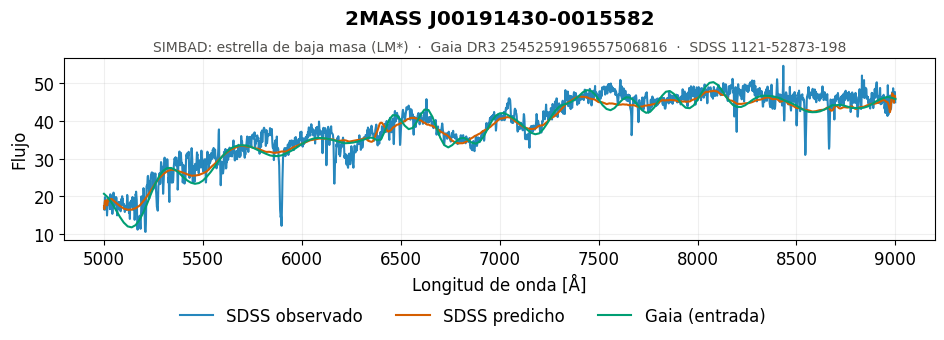

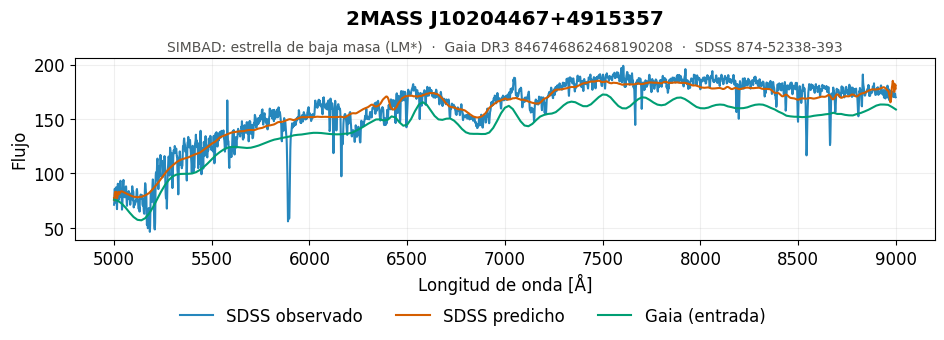

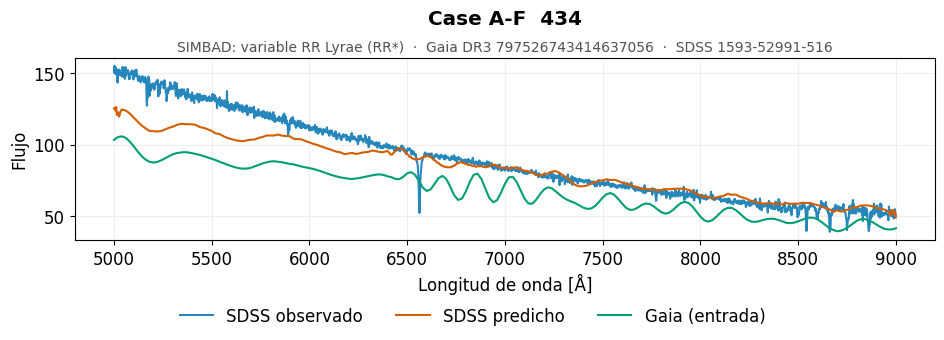

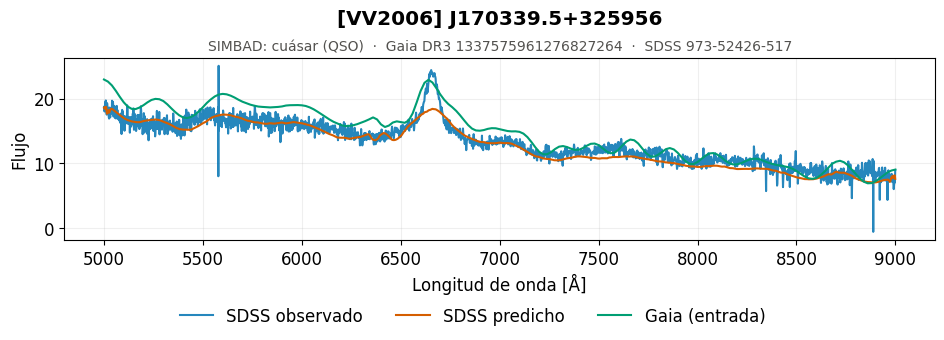

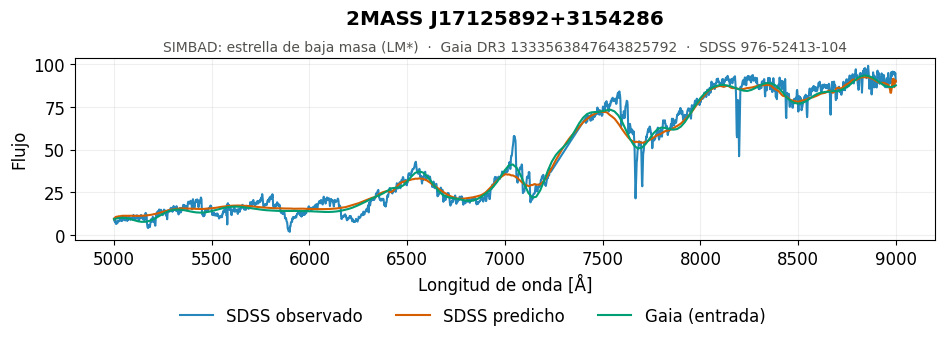

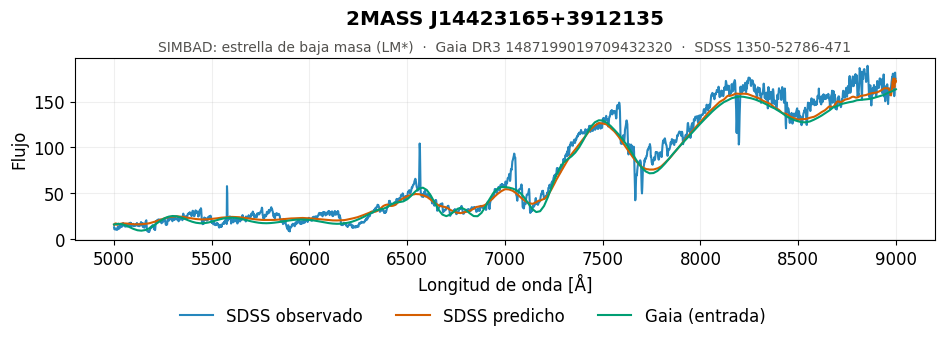

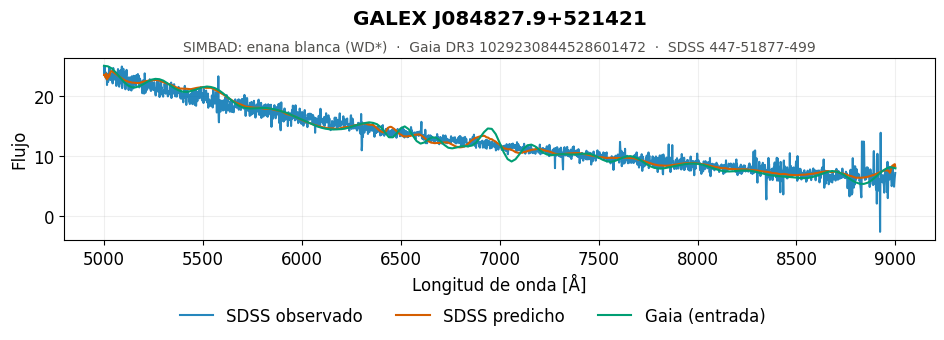

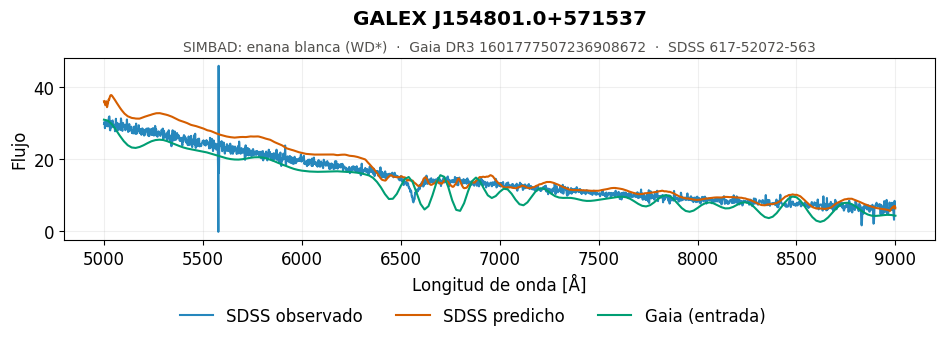

Imágenes guardadas en /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images


[PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/cnn_v1_main_sequence_central_2545259196557506816.png'),
 PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/cnn_v1_main_sequence_central_846746862468190208.png'),
 PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/cnn_v1_main_sequence_left_797526743414637056.png'),
 PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/cnn_v1_main_sequence_left_1337575961276827264.png'),
 PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/cnn_v1_main_sequence_right_1333563847643825792.png'),
 PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/cnn_v1_main_sequence_right_1487199019709432320.png'),
 PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/cnn_v1_white_dwarfs_1029230844528601472.png'),
 Posix

In [2]:
import sys

# 'plotting.py' vive en 'solution/services', y la celda de rutas solo añade
# 'models' a 'sys.path'. Las dos carpetas se llaman 'services', así que Python
# las une en un único paquete del que salen tanto 'services.paths' como
# 'services.plotting'
sys.path.insert(0, str(SOLUTION_DIR))

from services.plotting import SELECTED_OBJECTS_PATH, plot_selected_objects

# Comparativa sobre los mismos objetos en todos los cuadernos: la pareja de
# cada zona del diagrama HR que eligió 'services/simbad.py', encabezada por el
# nombre celeste oficial de cada objeto. Las figuras quedan guardadas en
# 'models/images' con el nombre que cita la memoria.
#
# La celda parte del CSV de objetos y de los `.npz` de test y de predicciones,
# así que se ejecuta suelta tras la de rutas: no reentrena, no vuelve a cargar
# el `.npz` de datos completo y no necesita las variables que dejen en memoria
# las demás celdas del cuaderno.
plot_selected_objects(
    SELECTED_OBJECTS_PATH,
    TEST_DATA_PATH,
    PREDICTIONS_PATH,
    "cnn_v1"
)


In [4]:
mae = np.mean(np.abs(y_test - y_pred))
mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")


MAE:  3.0979
MSE:  39.0254
RMSE: 6.2470


Chi cuadrado normalizado frente al espectro real de SDSS, la métrica con la que se comparan entre sí todas las arquitecturas del trabajo: la diferencia de flujo se pondera con la varianza inversa de SDSS y se divide entre el número de puntos válidos (aquellos cuya varianza inversa es mayor que cero). Se calcula sobre el flujo sin normalizar, de modo que los valores son comparables con los de los modelos denso y recurrente.

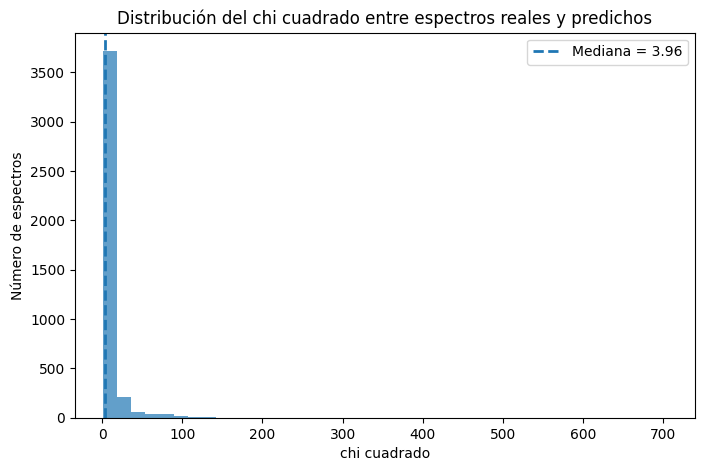

Mínimo:  1.06
Máximo:  704.61
Mediana:  3.96


In [14]:
chi2_values = calculate_all_chi2(y_test, y_pred, y_ivar_test)

print(f"Mediana: {np.median(chi2_values): .2f}")

In [15]:
# El modelo ya está guardado por el checkpoint; lo reescribimos por si esta
# sesión ha continuado el entrenamiento a partir de un checkpoint anterior
model_cnn.save(MODEL_PATH)

Validación física con iSpec: analizamos una muestra de espectros de test comparando los parámetros estelares (Teff, log g, [M/H]) derivados del espectro SDSS real frente a los derivados del espectro predicho por la red.

El proceso se reparte en tres celdas independientes —importaciones, recursos y análisis— para que repetir el análisis, que es con diferencia lo más lento, no vuelva a cargar los recursos.

Las predicciones son las de la celda de predicción, que carga el modelo guardado (`cnn_v1.keras`) y no requiere haber entrenado en esta sesión.

In [16]:
# Funciones de iSpec (el módulo está en 'models', ya añadido a sys.path)
from iSpec_functions import (
    load_ispec_resources,
    load_gaia_table,
    analyze_sample_real_vs_pred,
    analyze_ispec_errors
)

In [17]:
# Recursos de iSpec y tabla de Gaia. Las dos cargas están cacheadas en
# 'iSpec_functions', de modo que repetir esta celda no vuelve a leer de disco
resources = load_ispec_resources()

gaia_data_df = load_gaia_table()

/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/lib/iSpec/ispec/atmospheres.py:349: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  delaunay_triangulations, kdtree = pickle.load(open(cache_filename, 'rb'))



Recursos de iSpec cargados correctamente.
Tabla de Gaia cargada: 121890 objetos.


Espectros analizados:   0%|          | 0/250 [00:00<?, ?cuerpos estelares/s]

Error analizando el espectro real de 2538096737295072384: Initial teff '3463.60498046875' is out of range: '3500.0' - '50000.0'
Error analizando el espectro real de 1541549494377790976: Initial Vmac '69.0' is out of range: '0.0' - '50.0'




Error analizando el espectro real de 1580491584892970880: Initial teff '3470.390380859375' is out of range: '3500.0' - '50000.0'
Error analizando el espectro real de 705041494643881984: Initial Vmac '99.79' is out of range: '0.0' - '50.0'


[2026-09-04 04:31:29,645] [WARNING] [atmospheres:_interpolate:110]: Target point '3747.5984641406912 5.0 -4.023165337046569 0.0' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-09-04 04:31:30,745] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.


Error analizando el espectro real de 2545605714518955904: Initial teff '3458.80908203125' is out of range: '3500.0' - '50000.0'
Error analizando el espectro real de 3123413192472575104: Initial Vmac '61.38' is out of range: '0.0' - '50.0'
Error analizando el espectro real de 2543233827419669248: Initial teff '3367.34033203125' is out of range: '3500.0' - '50000.0'
Error analizando el espectro real de 1314845963554562048: Initial teff '3131.83984375' is out of range: '3500.0' - '50000.0'
Error analizando el espectro real de 2543177404432952576: Initial teff '3243.40625' is out of range: '3500.0' - '50000.0'
Error analizando el espectro real de 1010757163692550016: Initial teff '3373.503662109375' is out of range: '3500.0' - '50000.0'
Error analizando el espectro real de 2537819041889500160: Initial teff '3419.10302734375' is out of range: '3500.0' - '50000.0'
Error analizando el espectro real de 1604215300609762304: Initial teff '3435.130615234375' is out of range: '3500.0' - '50000.0'


[2026-09-04 05:15:08,179] [WARNING] [atmospheres:_interpolate:110]: Target point '3500.0 2.238782122031845 -4.258114191996689 0.00031999999191612005' is out of bound, using the closest
GAUSSJ: Singular Matrix-2
. . . now exiting to system . . .
[2026-09-04 05:15:09,280] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.
[2026-09-04 05:22:23,906] [WARNING] [atmospheres:_interpolate:110]: Target point '3500.0 5.0 -4.363556165934931 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-09-04 05:22:25,009] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.


Error analizando el espectro real de 1394500362602477184: Initial Vmac '151.26' is out of range: '0.0' - '50.0'
Error analizando el espectro real de 3267096031958970880: Initial teff '3341.4931640625' is out of range: '3500.0' - '50000.0'
Error analizando el espectro real de 2536119265632349440: Initial teff '3414.03125' is out of range: '3500.0' - '50000.0'
Error analizando el espectro real de 2536743616438313344: Initial teff '3487.251953125' is out of range: '3500.0' - '50000.0'
Error analizando el espectro real de 858606534186460800: Initial Vmac '139.37' is out of range: '0.0' - '50.0'
Error analizando el espectro real de 3847504615122111616: Initial Vmac '250.4' is out of range: '0.0' - '50.0'
Error analizando el espectro real de 3120288487803210496: Initial Vmac '88.64' is out of range: '0.0' - '50.0'


[2026-09-04 05:46:56,855] [WARNING] [atmospheres:_interpolate:110]: Target point '6884.510365295243 4.395903319210485 -5.5 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-09-04 05:46:57,972] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.


Error analizando el espectro real de 3265951891326617984: Initial teff '3302.129150390625' is out of range: '3500.0' - '50000.0'
Espectros analizados: 250 | ajustes reutilizados: 250 reales, 0 predichos


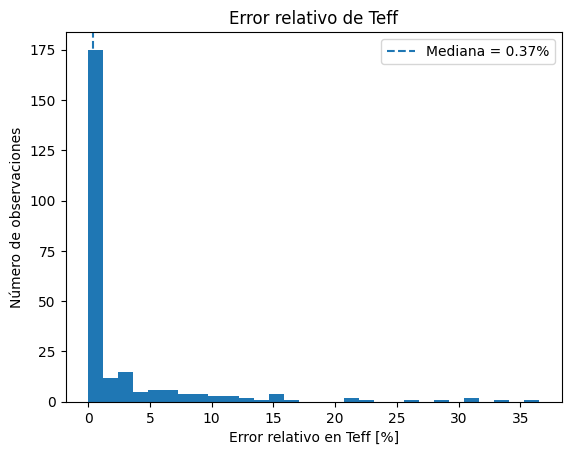

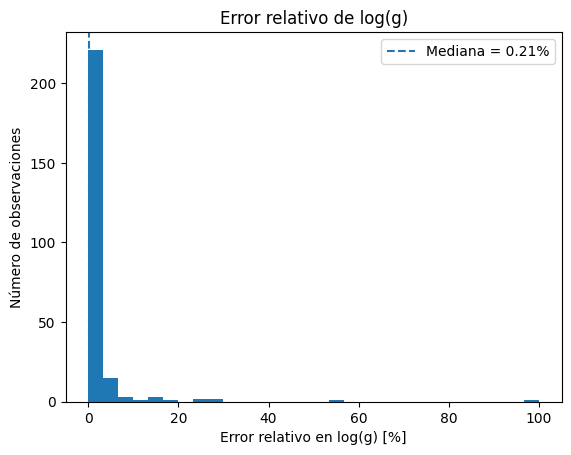

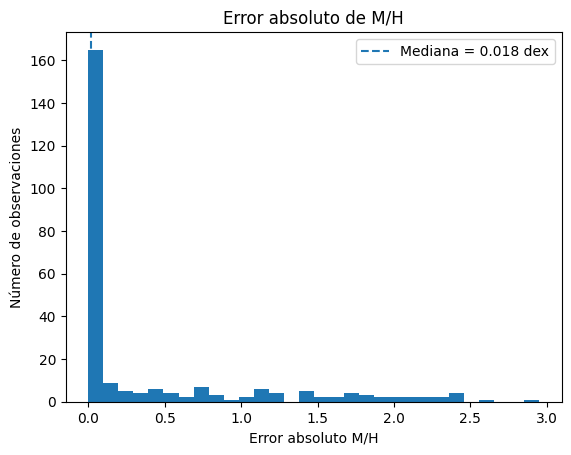

In [18]:
# Analizamos con iSpec una muestra de espectros reales frente a predichos
results_df_cnn = analyze_sample_real_vs_pred(
    y_test,
    y_pred,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=250
)

# Guardamos la tabla nada más calcularla: el análisis son horas de iSpec, y así
# los histogramas de error se rehacen sin repetirlo
ISPEC_PATH.parent.mkdir(parents=True, exist_ok=True)

results_df_cnn.to_csv(
    ISPEC_PATH,
    index=False
)

error_df_cnn = analyze_ispec_errors(results_df_cnn)